In [23]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv(
    "hotel_bookings.csv",
    keep_default_na=False
)

df.shape

(12000, 28)

In [25]:
date_cols = [
    'booking_date',
    'checkin_date',
    'checkout_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   booking_id             12000 non-null  int64         
 1   customer_id            12000 non-null  int64         
 2   customer_name          12000 non-null  object        
 3   customer_segment       12000 non-null  object        
 4   customer_signup_date   12000 non-null  object        
 5   customer_home_city     12000 non-null  object        
 6   customer_loyalty_tier  12000 non-null  object        
 7   property_id            12000 non-null  int64         
 8   property_name          12000 non-null  object        
 9   property_city          12000 non-null  object        
 10  property_star_rating   12000 non-null  int64         
 11  property_type          12000 non-null  object        
 12  property_total_rooms   12000 non-null  int64         
 13  b

In [26]:
# Realized Revenue Only
# Only Completed bookings count as realized revenue.

completed = df[
    df['booking_status']
    == 'Completed'
].copy()

completed.shape

(9333, 28)

In [27]:
# Create Monthly Revenue Table

completed['month'] = (
    completed['booking_date']
    .dt.to_period('M')
    .astype(str)
)

monthly_revenue = (
    completed.groupby('month')
    ['total_amount']
    .sum()
    .reset_index()
)

monthly_revenue.head()

,month,total_amount
0,2021-10,20542.57
1,2021-11,112489.90
2,2021-12,112073.50
3,2022-01,61254.07
4,2022-02,133000.69


**API Call**

In [28]:
# Real API Call with Error Handling

url = (
    "https://api.frankfurter.app/latest"
    "?base=INR"
    "&symbols=USD,EUR,GBP"
)

try:

    response = requests.get(
        url,
        timeout=10
    )

    response.raise_for_status()

    fx_data = response.json()

    print("API Success")

    print(fx_data)

except Exception as e:

    print("API Error")

    print(e)

API Success
{'amount': 1.0, 'base': 'INR', 'date': '2026-06-19', 'rates': {'EUR': 0.00924, 'GBP': 0.00801, 'USD': 0.0106}}


## Extract USD, EUR and GBP Rates

In [29]:
usd_rate = (
    fx_data['rates']['USD']
)

eur_rate = (
    fx_data['rates']['EUR']
)

gbp_rate = (
    fx_data['rates']['GBP']
)

print("USD:", usd_rate)
print("EUR:", eur_rate)
print("GBP:", gbp_rate)

USD: 0.0106
EUR: 0.00924
GBP: 0.00801


In [30]:
# Create month start date for API lookup

monthly_revenue['fx_date'] = (
    pd.to_datetime(
        monthly_revenue['month']
    )
)

monthly_revenue.head()

,month,total_amount,fx_date
0,2021-10,20542.57,2021-10-01
1,2021-11,112489.90,2021-11-01
2,2021-12,112073.50,2021-12-01
3,2022-01,61254.07,2022-01-01
4,2022-02,133000.69,2022-02-01


In [31]:
# Historical FX Function

def get_usd_rate(date):

    url = (
        f"https://api.frankfurter.app/"
        f"{date.strftime('%Y-%m-%d')}"
        "?base=INR&symbols=USD"
    )

    try:

        response = requests.get(
            url,
            timeout=10
        )

        response.raise_for_status()

        data = response.json()

        return data['rates']['USD']

    except Exception as e:

        print(
            f"Error fetching rate for {date}"
        )

        return None

In [32]:
# Fetch Monthly Historical Rates

monthly_revenue['usd_rate'] = (
    monthly_revenue['fx_date']
    .apply(get_usd_rate)
)

monthly_revenue

,month,total_amount,fx_date,usd_rate
0,2021-10,20542.57,2021-10-01,0.01349
1,2021-11,112489.90,2021-11-01,0.01335
2,2021-12,112073.50,2021-12-01,0.01335
3,2022-01,61254.07,2022-01-01,0.01345
4,2022-02,133000.69,2022-02-01,0.01337
5,2022-03,197592.43,2022-03-01,0.01321
6,2022-04,42994.83,2022-04-01,0.01316
7,2022-05,472773.01,2022-05-01,0.01307
8,2022-06,3897.98,2022-06-01,0.01290
9,2022-07,98309.91,2022-07-01,0.01266


In [33]:
# FX Adjusted Revenue

monthly_revenue['revenue_usd_historical'] = (

    monthly_revenue['total_amount']

    *

    monthly_revenue['usd_rate']

)

monthly_revenue.head()

,month,total_amount,fx_date,usd_rate,revenue_usd_historical
0,2021-10,20542.57,2021-10-01,0.01349,277.119269
1,2021-11,112489.90,2021-11-01,0.01335,1501.740165
2,2021-12,112073.50,2021-12-01,0.01335,1496.181225
3,2022-01,61254.07,2022-01-01,0.01345,823.867241
4,2022-02,133000.69,2022-02-01,0.01337,1778.219225


In [34]:
# Compare Growth Before and After FX Adjustment

monthly_revenue['inr_growth_pct'] = (
    monthly_revenue['total_amount']
    .pct_change()
    * 100
)

monthly_revenue['usd_growth_pct'] = (
    monthly_revenue['revenue_usd_historical']
    .pct_change()
    * 100
)

monthly_revenue[
    [
        'month',
        'inr_growth_pct',
        'usd_growth_pct'
    ]
]

,month,inr_growth_pct,usd_growth_pct
0,2021-10,NaN,NaN
1,2021-11,447.594094,441.911130
2,2021-12,-0.370167,-0.370167
3,2022-01,-45.344734,-44.935331
4,2022-02,117.129556,115.838079
5,2022-03,48.564966,46.787076
6,2022-04,-78.240649,-78.323009
7,2022-05,999.604325,992.084234
8,2022-06,-99.175507,-99.186231
9,2022-07,2422.073228,2375.150935


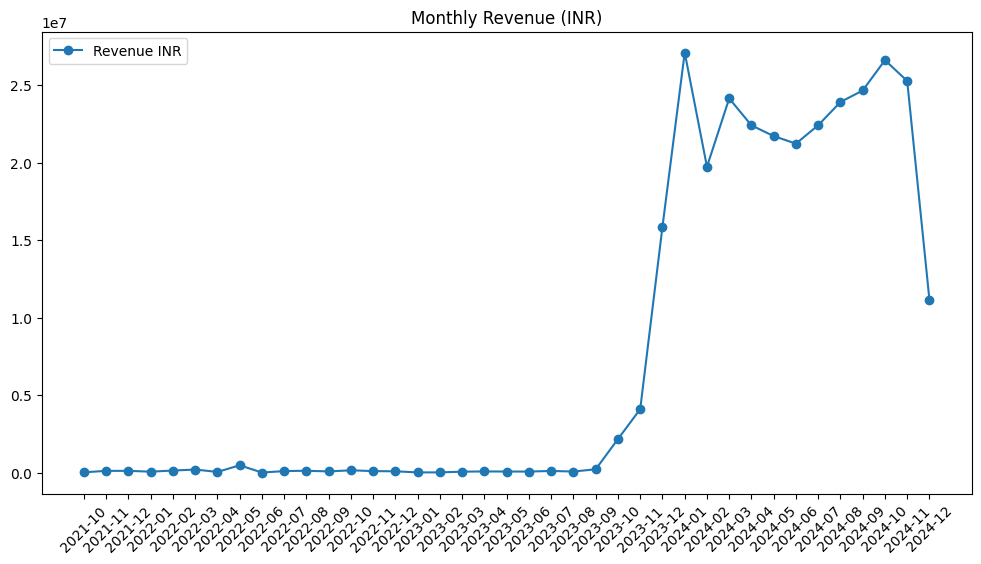

In [35]:
# Monthly Revenue in INR

plt.figure(
    figsize=(12,6)
)

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['total_amount'],
    marker='o',
    label='Revenue INR'
)

plt.xticks(rotation=45)

plt.legend()

plt.title(
    'Monthly Revenue (INR)'
)

plt.show()

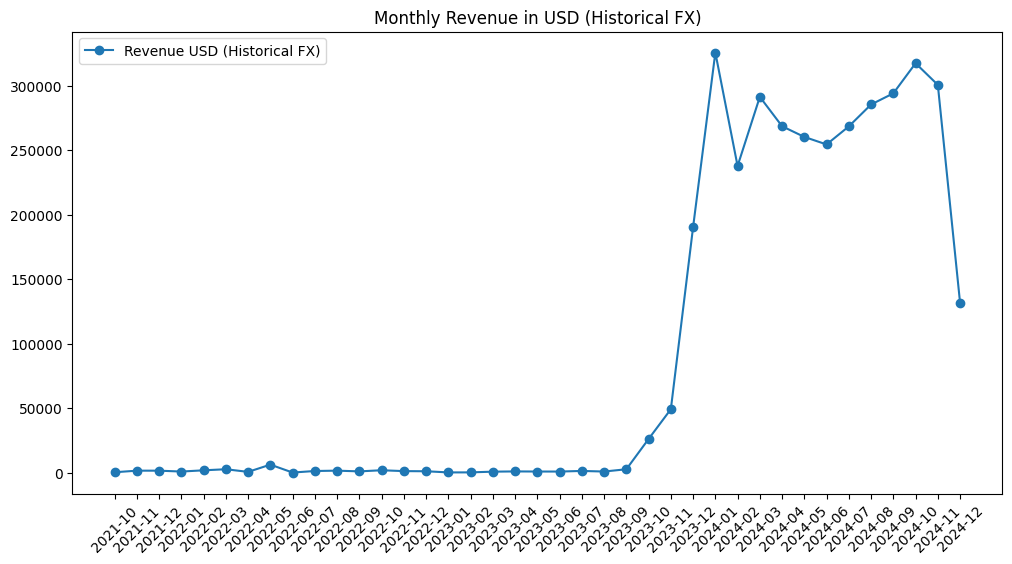

In [36]:
# Monthly Revenue in USD (Historical FX)

plt.figure(
    figsize=(12,6)
)

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['revenue_usd_historical'],
    marker='o',
    label='Revenue USD (Historical FX)'
)

plt.xticks(rotation=45)

plt.legend()

plt.title(
    'Monthly Revenue in USD (Historical FX)'
)

plt.show()

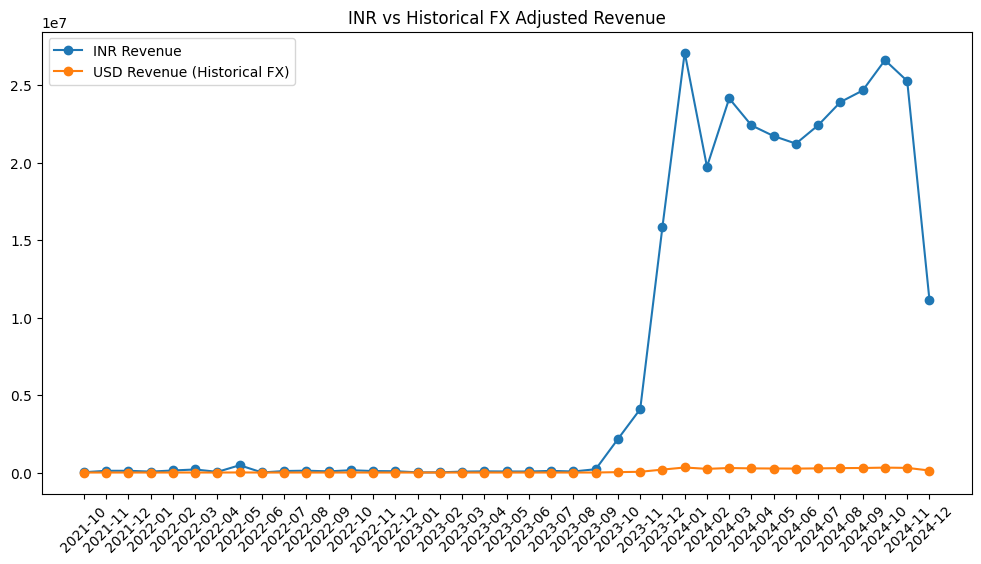

In [37]:
# Combined Comparison

plt.figure(
    figsize=(12,6)
)

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['total_amount'],
    marker='o',
    label='INR Revenue'
)

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['revenue_usd_historical'],
    marker='o',
    label='USD Revenue (Historical FX)'
)

plt.xticks(rotation=45)

plt.legend()

plt.title(
    'INR vs Historical FX Adjusted Revenue'
)

plt.show()

In [38]:
monthly_revenue.to_csv(
    "monthly_fx_report.csv",
    index=False
)

print("Report exported successfully.")

Report exported successfully.
